# BFS on Tree

**What is BFS?**  
BFS stands for Breadth-First Search, it visits nodes **level by level** starting from the root, then all children, then all grandchildren, and so on

**What is a Tree?**  
A tree is a graph with no cycles, 
Every node has exactly one parent (except the root)

**Libraries used:**
- `networkx` to build and work with graphs
- `matplotlib` to draw and visualize the graph

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

In [2]:
# create an empty graph (undirected)
T = nx.Graph()

# Add edges this automatically creates the nodes too
T.add_edges_from([
    (1, 2), (1, 3),        # root 1 connects to 2 and 3
    (2, 4), (2, 5),        # node 2 connects to 4 and 5
    (3, 6), (3, 7),        # node 3 connects to 6 and 7
    (4, 8)                 # node 4 connects to 8
])

print("nodes:", list(T.nodes()))
print("edges:", list(T.edges()))

nodes: [1, 2, 3, 4, 5, 6, 7, 8]
edges: [(1, 2), (1, 3), (2, 4), (2, 5), (3, 6), (3, 7), (4, 8)]


In [3]:
def bfs(graph, start):
    """
    BFS traversal on a graph
    returns visited order and each node's BFS level
    """
    visited = []          # nodes we already visited
    levels = {}           # level of each node (distance from start)
    queue = deque()       # queue: first in, first out

    queue.append(start)
    levels[start] = 0

    while queue:
        node = queue.popleft()        # take the first node in queue

        if node not in visited:
            visited.append(node)

            for neighbor in graph.neighbors(node):
                if neighbor not in levels:
                    levels[neighbor] = levels[node] + 1
                    queue.append(neighbor)

    return visited, levels

# run BFS starting from node 1
visited_order, node_levels = bfs(T, start=1)

print("BFS visited order:", visited_order)
print("node levels:", node_levels)

BFS visited order: [1, 2, 3, 4, 5, 6, 7, 8]
node levels: {1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 2, 8: 3}


In [4]:
# assign color based on BFS level
level_colors = {
    0: "#E8593C",   # root: coral/red
    1: "#EF9F27",   # level 1: amber
    2: "#1D9E75",   # level 2: teal
    3: "#378ADD",   # level 3: blue
}

node_color_list = [level_colors[node_levels[n]] for n in T.nodes()]

# use tree layout
pos = nx.spring_layout(T, seed=42)

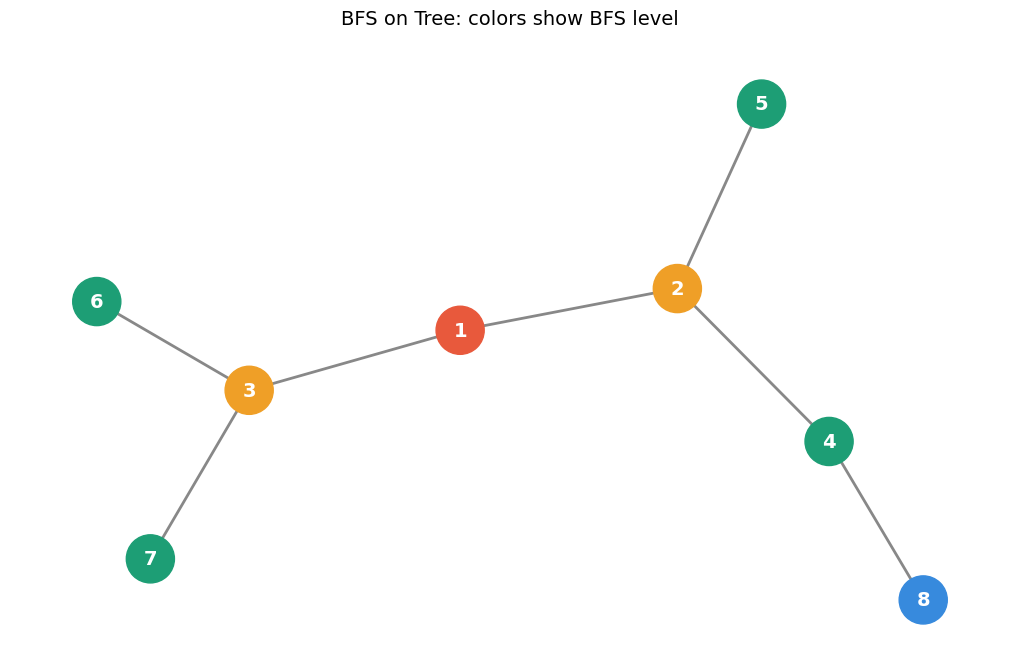

BFS order: [1, 2, 3, 4, 5, 6, 7, 8]


In [5]:
plt.figure(figsize=(10, 6))

nx.draw(
    T,
    pos=pos,
    with_labels=True,
    node_color=node_color_list,
    node_size=1200,
    font_size=14,
    font_color="white",
    font_weight="bold",
    edge_color="#888888",
    width=2
)

plt.title("BFS on Tree: colors show BFS level", fontsize=14, pad=20)
plt.savefig("../images/bfs_tree_result.png", dpi=150, bbox_inches="tight")
plt.show()

print("BFS order:", visited_order)

## What just happened?

| Color | Level | Nodes |
|-------|-------|-------|
| 🔴 Red | 0: root | 1 |
| 🟠 Amber | 1: children | 2, 3 |
| 🟢 Teal | 2: grandchildren | 4, 5, 6, 7 |
| 🔵 Blue | 3: great-grandchildren | 8 |

BFS visits all nodes at level 1 **before** going to level 2

This is the key difference from DFS (Depth-First Search)